In [2]:
import os
import sys

# add the directory containing the notebook to Python path
sys.path.append(os.getcwd())

import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

A7.5 (b) Estimating a vector with unknown measurement nonlinearity

status: optimal
optimal value: 2.142010610740412
x_ml:
[ 0.481939 -0.465687  0.936397  0.929651]


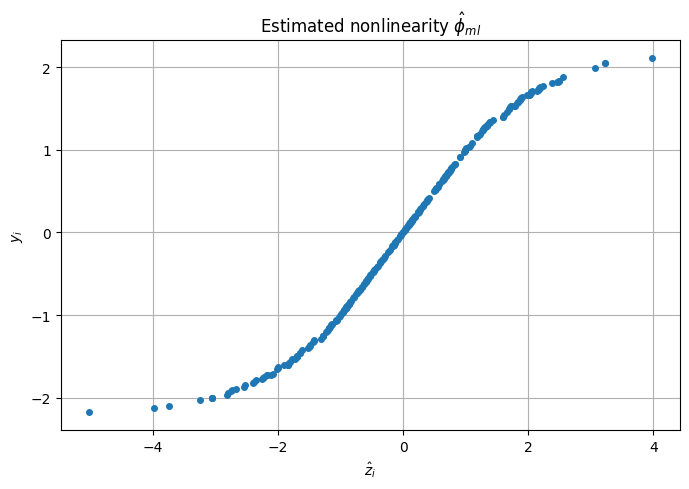

In [4]:
import nonlin_meas_data as data

# Extract data
A = data.A
y = data.y.flatten()
alpha = float(data.alpha)
beta = float(data.beta)

m, n = A.shape

x = cp.Variable(n)
z = cp.Variable(m)

dy = np.diff(y)
constraints = [
    z[1:] - z[:-1] >= (1 / beta) * dy,
    z[1:] - z[:-1] <= (1 / alpha) * dy,
]

objective = cp.Minimize(cp.sum_squares(z - A @ x))
prob = cp.Problem(objective, constraints)
prob.solve()

# solution
x_ml = x.value
z_ml = z.value

# Print results
np.set_printoptions(precision=6, suppress=True)
print("status:", prob.status)
print("optimal value:", prob.value)
print("x_ml:")
print(x_ml)

# Plot estimated nonlinearity 
plt.figure(figsize=(7, 5))
plt.plot(z_ml, y, "o", markersize=4)
plt.xlabel(r"$\hat z_i$")
plt.ylabel(r"$y_i$")
plt.title(r"Estimated nonlinearity $\hat{\phi}_{ml}$")
plt.grid(True)
plt.tight_layout()
plt.show()